# Kapitola 2: Podmíněná pravděpodobnost a nezávislost náhodných jevů

## 2.1 Podmíněná pravděpodobnost


**Definice 2.1**  
Podmíněná pravděpodobnost jevu $A$ za podmínky jevu $B$ (kde $P(B) > 0$) je definována jako:

$$
P(A|B) = \frac{P(A \cap B)}{P(B)}
$$


### Ukázka výpočtu podmíněné pravděpodobnosti v Pythonu

In [3]:
# Pravděpodobnosti jevů A a B
P_A = 0.6
P_B = 0.5
P_A_and_B = 0.3

# Výpočet podmíněné pravděpodobnosti P(A|B)
P_A_given_B = P_A_and_B / P_B
print(f"Podmíněná pravděpodobnost P(A|B) = {P_A_given_B:.2f}")

Podmíněná pravděpodobnost P(A|B) = 0.60


### Sensitivita, Specificita a Prediktivní hodnoty
https://en.wikipedia.org/wiki/Sensitivity_and_specificity
#### Sensitivita (citlivost)
- **Definice:** Pravděpodobnost, že test správně identifikuje jedince s onemocněním (skutečně nemocné označí jako pozitivní).
- **Vzorec:**  
  $$
  \text{Sensitivita} = \frac{\text{TP}}{\text{TP} + \text{FN}}
  $$
- **Význam:**  
  Vysoká sensitivita znamená málo falešně negativních výsledků.

---

#### Specificita (specifičnost)
- **Definice:** Pravděpodobnost, že test správně identifikuje jedince bez onemocnění (skutečně zdravé označí jako negativní).
- **Vzorec:**  
  $$
  \text{Specificita} = \frac{\text{TN}}{\text{TN} + \text{FP}}
  $$
- **Význam:**  
  Vysoká specificita znamená málo falešně pozitivních výsledků.

---

### Prediktivní hodnoty

#### Pozitivní prediktivní hodnota (PPV)
- **Definice:** Pravděpodobnost, že jedinec s pozitivním výsledkem testu je skutečně nemocný.
- **Vzorec:**  
  $$
  \text{PPV} = \frac{\text{TP}}{\text{TP} + \text{FP}}
  $$
- **Význam:**  
  Odpovídá na otázku: „Pokud je test pozitivní, jaká je šance, že je člověk opravdu nemocný?“

#### Negativní prediktivní hodnota (NPV)
- **Definice:** Pravděpodobnost, že jedinec s negativním výsledkem testu je skutečně zdravý.
- **Vzorec:**  
  $$
  \text{NPV} = \frac{\text{TN}}{\text{TN} + \text{FN}}
  $$
- **Význam:**  
  Odpovídá na otázku: „Pokud je test negativní, jaká je šance, že je člověk opravdu zdravý?“

---

### Shrnutí v tabulce

|                       | Skutečně nemocný | Skutečně zdravý |
|-----------------------|:----------------:|:---------------:|
| **Test pozitivní**    | TP (pravá pozitivita) | FP (falešná pozitivita) |
| **Test negativní**    | FN (falešná negativita) | TN (pravá negativita)   |

---

**Poznámky:**
- Sensitivita a specificita jsou vlastnosti testu, nezávislé na výskytu onemocnění v populaci.
- Prediktivní hodnoty (PPV a NPV) závisí na **incidenci** (výskytu) onemocnění v populaci.


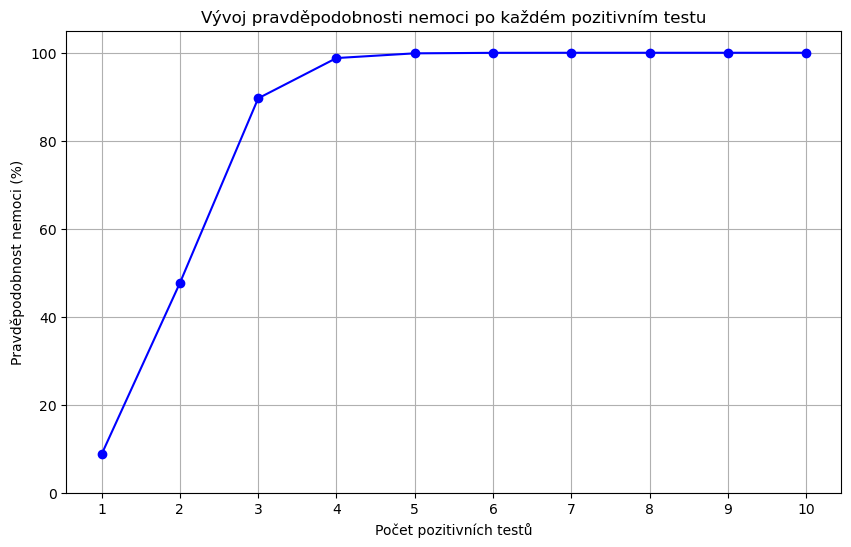

In [4]:
import matplotlib.pyplot as plt

# Parametry testu a incidence
incidence = 0.01         # P(Disease)
sensitivity = 0.95       # P(Pos | Disease)
specificity = 0.90       # P(Neg | No Disease)
false_positive_rate = 1 - specificity  # P(Pos | No Disease)

# Počet opakování testu
num_tests = 10

# Seznam pro ukládání pravděpodobností po každém testu
posterior_probs = []

# Počáteční pravděpodobnost (před testováním)
prior = incidence

# Bayesovská aktualizace po každém pozitivním testu
for i in range(num_tests):
    numerator = sensitivity * prior
    denominator = numerator + false_positive_rate * (1 - prior)
    posterior = numerator / denominator
    posterior_probs.append(posterior)
    prior = posterior  # Aktualizace prioru pro další test

# Vykreslení grafu
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_tests + 1), [p * 100 for p in posterior_probs], marker='o', color='blue')
plt.title('Vývoj pravděpodobnosti nemoci po každém pozitivním testu')
plt.xlabel('Počet pozitivních testů')
plt.ylabel('Pravděpodobnost nemoci (%)')
plt.grid(True)
plt.ylim(0, 105)
plt.xticks(range(1, num_tests + 1))
plt.show()



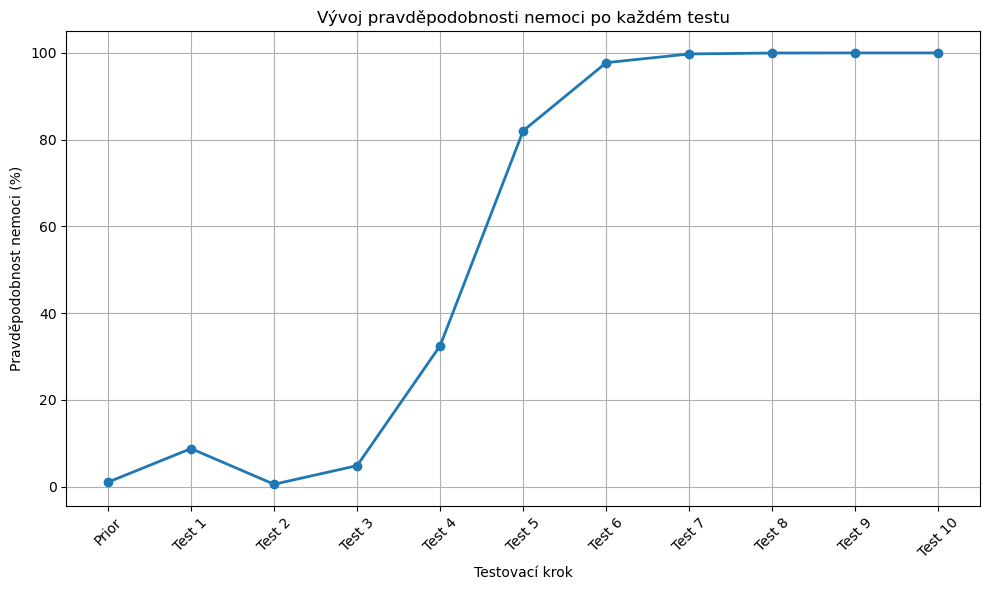

Pravděpodobnost správné diagnózy po 10 testech: 99.9997 %
Pravděpodobnost falešné diagnózy: 0.0003 %


In [5]:
import matplotlib.pyplot as plt
import numpy as np
# Parametry testu a incidence
incidence = 0.01         # P(Disease)
sensitivity = 0.95       # P(Pos | Disease)
specificity = 0.90       # P(Neg | No Disease)

# Sekvence výsledků testů (True = pozitivní, False = negativní)
test_results = [True, True, False, True, False, True, True, False, False, True]
positive_prob = 0.90     # Probability that a test returns positive

# Generate random test results: True = positive, False = negative
np.random.seed(42)  # For reproducibility
test_results = np.random.choice([True, False], size=num_tests, p=[positive_prob, 1 - positive_prob])


# Funkce pro výpočet pravděpodobnosti nemoci po každém testu
def bayesian_update(prior, result, sensitivity, specificity):
    if result:  # Pozitivní test
        numerator = sensitivity * prior
        denominator = numerator + (1 - specificity) * (1 - prior)
    else:       # Negativní test
        numerator = (1 - sensitivity) * prior
        denominator = numerator + specificity * (1 - prior)
    return numerator / denominator

# Výpočet vývoje pravděpodobnosti
probabilities = [incidence]
for result in test_results:
    updated = bayesian_update(probabilities[-1], result, sensitivity, specificity)
    probabilities.append(updated)

# Vykreslení grafu
plt.figure(figsize=(10, 6))
plt.plot(range(len(probabilities)), [p * 100 for p in probabilities], marker='o', linewidth=2)
plt.xticks(range(len(probabilities)), labels=[f'Test {i}' if i > 0 else 'Prior' for i in range(len(probabilities))], rotation=45)
plt.xlabel('Testovací krok')
plt.ylabel('Pravděpodobnost nemoci (%)')
plt.title('Vývoj pravděpodobnosti nemoci po každém testu')
plt.grid(True)
plt.tight_layout()
plt.show()

# Výsledky
final_probability = probabilities[-1]
false_diagnosis_probability = 1 - final_probability

print(f"Pravděpodobnost správné diagnózy po 10 testech: {final_probability * 100:.4f} %")
print(f"Pravděpodobnost falešné diagnózy: {false_diagnosis_probability * 100:.4f} %")




### Příklad z lékařské diagnostiky

Níže uvedený příklad je převzatý z knihy *Jiří Anděl: Matematika náhody* (Matfyzpress 2003) https://matfyzpress.cz/cz/e-shop/vsechny-tituly/matematika-nahody-9788073784201.

Mead (1992) uvádí následující příklad, o němž píše, že ho převzal od prof. Aitchinsona. Předběžná vyšetření ukazují, že pacient má netoxickou strumu. Tato choroba může mít jednu ze tří forem:

- **A** — obyčejná struma  
- **B** — Hashimotova nemoc  
- **C** — rakovina štítné žlázy

Pro jednoduchost budeme nazývat tyto formy nemoci chorobou A, B a C. K rozpoznání přesné diagnózy se používá osm testů. Žádný z nich není úplně spolehlivý. Na základě mnoha zkušeností s dřívějšími pacienty je spolehlivost těchto testů uvedena v tabulce 1.2.

Tabulka 1.2: Procento pozitivních odpovědí

| Nemoc | T1 | T2 | T3 | T4 | T5 | T6 | T7 | T8 |
|-------|----|----|----|----|----|----|----|----|
| A     | 30 | 20 | 50 | 70 | 40 | 80 | 60 | 60 |
| B     | 70 | 30 | 90 | 80 | 20 | 40 | 90 | 50 |
| C     | 60 | 80 | 40 | 20 | 60 | 70 | 50 | 10 |

Trpí-li pacient chorobou A, pak první test bude u něj pozitivní s pravděpodobností **0,3**.

Trpí-li však chorobou B, pak první test mu dá pozitivní výsledek s pravděpodobností **0,7** atd. Podobně se čtou další údaje v tabulce 1.2.

Předpokládejme pro jednoduchost, že se všechny tři formy netoxické strumy vyskytují stejně často. Pak jejich apriorní pravděpodobnosti \( P(A) \), \( P(B) \) a \( P(C) \) budou stejné, takže:

$$
P(A) = P(B) = P(C) = \frac{1}{3}
$$

Předpokládejme, že u daného pacienta byly postupně provedeny testy 1 až 8 (v tomto pořadí) a že se získaly výsledky uvedené v tabulce 1.3.

Tabulka 1.3: Výsledky lékařských testů

| Test 1 | Test 2 | Test 3 | Test 4 | Test 5 | Test 6 | Test 7 | Test 8 |
|--------|--------|--------|--------|--------|--------|--------|--------|
| +      | +      | +      | +      | --     | --     | --     | +      |


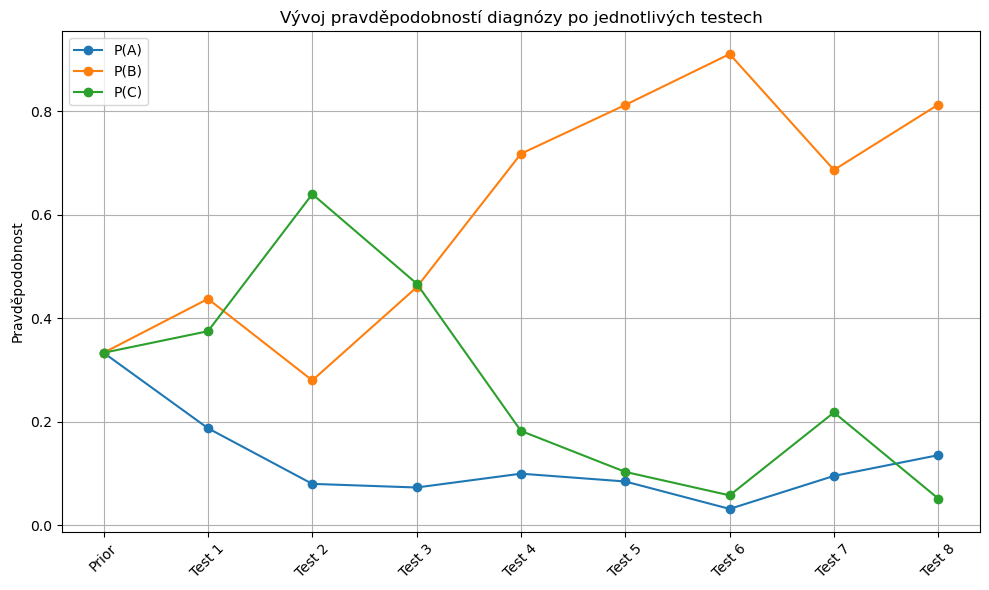

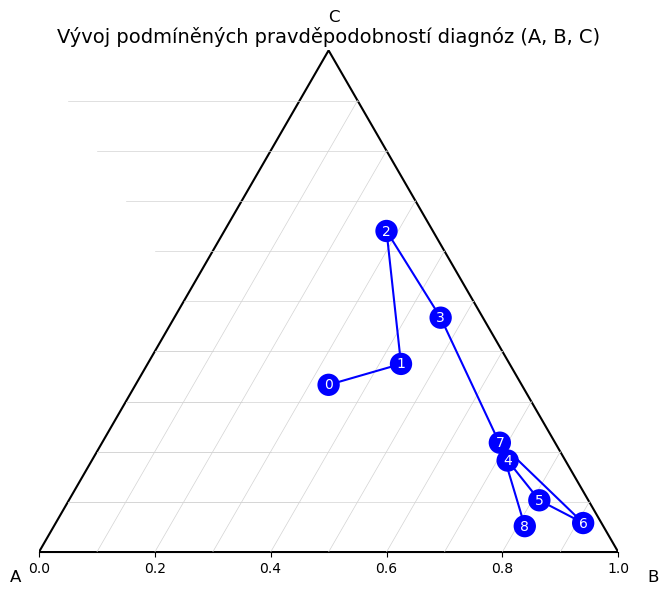

In [9]:
# -*- coding: utf-8 -*-
"""
Created on Fri Sep 19 15:44:38 2025

@author: sediva
"""
import matplotlib.pyplot as plt
import numpy as np

# Data from Table 1.2: probabilities of positive test results for each disease
prob_table = {
    'A': [0.3, 0.2, 0.5, 0.7, 0.4, 0.8, 0.6, 0.6],
    'B': [0.7, 0.3, 0.9, 0.8, 0.2, 0.4, 0.9, 0.5],
    'C': [0.6, 0.8, 0.4, 0.2, 0.6, 0.7, 0.5, 0.1]
}

# Test results from Table 1.3: '+' means positive, '-' means negative
test_results = [True, True, True, True, False, False, False, True]

# Initial prior probabilities
prior = np.array([1/3, 1/3, 1/3])
trajectory = [prior]

# Apply Bayes' rule iteratively for each test
for i, result in enumerate(test_results):
    likelihood = np.array([
        prob_table['A'][i] if result else 1 - prob_table['A'][i],
        prob_table['B'][i] if result else 1 - prob_table['B'][i],
        prob_table['C'][i] if result else 1 - prob_table['C'][i]
    ])
    posterior = prior * likelihood
    posterior /= posterior.sum()
    trajectory.append(posterior)
    prior = posterior

trajectory = np.array(trajectory)

# Prepare data for line plot
labels = ['Prior'] + [f'Test {i+1}' for i in range(len(test_results))]
A_probs = trajectory[:, 0]
B_probs = trajectory[:, 1]
C_probs = trajectory[:, 2]

plt.figure(figsize=(10, 6))
plt.plot(labels, A_probs, marker='o', label='P(A)')
plt.plot(labels, B_probs, marker='o', label='P(B)')
plt.plot(labels, C_probs, marker='o', label='P(C)')
plt.xticks(rotation=45)
plt.ylabel('Pravděpodobnost')
plt.title('Vývoj pravděpodobností diagnózy po jednotlivých testech')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

# Convert to ternary coordinates
def ternary_coords(p):
    a, b, c = p
    x = 0.5 * (2*b + c) / (a + b + c)
    y = (np.sqrt(3)/2) * c / (a + b + c)
    return x, y

coords = np.array([ternary_coords(p) for p in trajectory])


# Plotting the ternary diagram
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_xlim(0, 1)
ax.set_ylim(0, np.sqrt(3)/2)

# Draw triangle
triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])
ax.plot(triangle[:,0], triangle[:,1], 'k-')

# Draw grid lines
for i in range(1, 10):
    f = i / 10
    # Lines parallel to AB
    ax.plot([f/2, 1 - f/2], [f*np.sqrt(3)/2, f*np.sqrt(3)/2], color='lightgray', linewidth=0.5)
    # Lines parallel to BC
    ax.plot([f, (1+f)/2], [0, (1-f)*np.sqrt(3)/2], color='lightgray', linewidth=0.5)
    # Lines parallel to CA
    ax.plot([(1-f)/2, f/2], [(1-f)*np.sqrt(3)/2, (1-f)*np.sqrt(3)/2], color='lightgray', linewidth=0.5)

# Label corners
ax.text(-0.05, -0.05, 'A', fontsize=12)
ax.text(1.05, -0.05, 'B', fontsize=12)
ax.text(0.5, np.sqrt(3)/2 + 0.05, 'C', fontsize=12)

# Plot trajectory
ax.plot(coords[:,0], coords[:,1], 'o-', color='blue')
for i, (x, y) in enumerate(coords):
    ax.text(x, y, str(i), fontsize=10, ha='center', va='center', color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='circle'))

ax.set_title("Vývoj podmíněných pravděpodobností diagnóz (A, B, C)", fontsize=14)

ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.xaxis.set_visible(True)
ax.yaxis.set_visible(False)

plt.tight_layout()
plt.show()




## 2.2 Nezávislé jevy


**Definice 2.5**  
Dva jevy $A$ a $B$ jsou nezávislé, pokud platí:

$$
P(A \cap B) = P(A) \cdot P(B)
$$

**Věta 2.6**  
Pro dva nezávislé jevy $A$ a $B$ platí:
- $P(A|B) = P(A)$ a $P(B|A) = P(B)$
- $P(A \cup B) = P(A) + P(B) - P(A) \cdot P(B)$
- Jevy $\overline{A}$ a $\overline{B}$ jsou nezávislé, stejně jako $A$ a $\overline{B}$, $\overline{A}$ a $B$




**🎲 Monty Hallův problém**

https://cs.wikipedia.org/wiki/Monty_Hall%C5%AFv_probl%C3%A9m

Představte si, že jste soutěžící v televizní show. Před vámi jsou *tři dveře*:

- Za jedněmi dveřmi je *auto* (výhra),
- za zbývajícími dvěma jsou *kozy* (nevýhra).

*Pravidla hry:*

1. Vyberete jedny dveře (např. dveře č. 1).
2. Moderátor, který *ví*, co se skrývá za každými dveřmi, *otevře jedny z ostatních dveří*, za kterými je *koza*.
3. Nabídne vám možnost *změnit svou volbu* – tedy přejít na třetí, dosud neotevřené dveře.

**Otázka:**

Měli byste zůstat u původní volby, nebo ji změnit?

---

**🎯 Simulační postup:**

Porovnat dvě strategie:

- *Zůstat* u původní volby.
- *Změnit* volbu po odhalení kozy.

Pomocí simulace 10 000 her zjistíme, která strategie vede častěji k výhře.

---

**📊 Očekávaný výsledek:**

- Strategie „Změnit“ má teoreticky *pravděpodobnost výhry 2/3*.
- Strategie „Zůstat“ má pravděpodobnost výhry *1/3*.
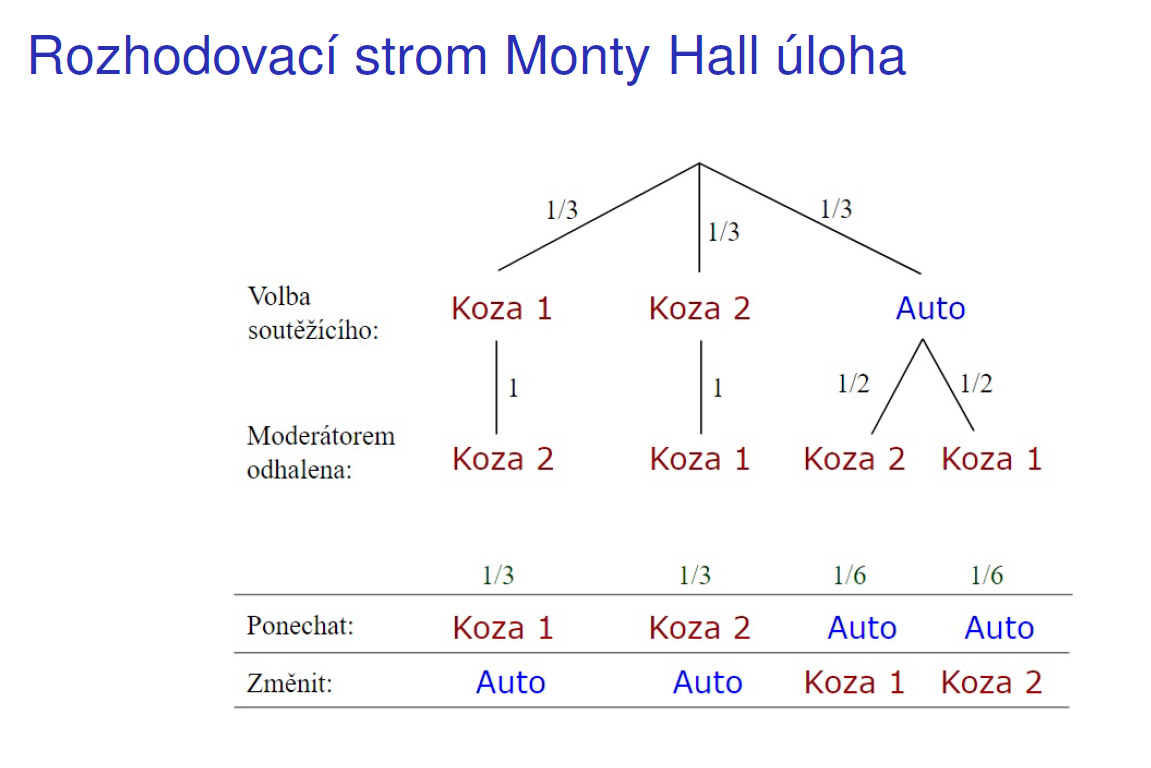
Simulace by měla tyto výsledky potvrdit.


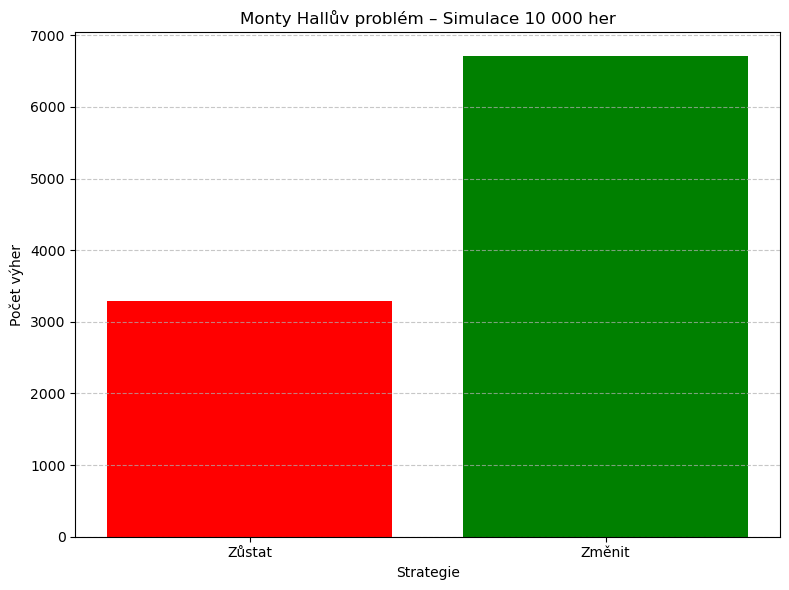

In [7]:
import random
import matplotlib.pyplot as plt

# Funkce pro simulaci Monty Hallova problému
def monty_hall_simulace(pocet_simulaci=10000):
    zustat_vyhra = 0
    zmenit_vyhra = 0

    for _ in range(pocet_simulaci):
        # Náhodně umístíme auto za jedny ze tří dveří
        auto = random.randint(0, 2)
        vyber_hrace = random.randint(0, 2)

        # Moderátor otevře dveře s kozou, které nejsou vybrané hráčem ani neobsahují auto
        moznosti = [i for i in range(3) if i != vyber_hrace and i != auto]
        otevrene_dvere = random.choice(moznosti)

        # Dveře, které zbývají po otevření jedněch s kozou
        zbyvajici_dvere = [i for i in range(3) if i != vyber_hrace and i != otevrene_dvere][0]

        # Strategie: zůstat
        if vyber_hrace == auto:
            zustat_vyhra += 1

        # Strategie: změnit
        if zbyvajici_dvere == auto:
            zmenit_vyhra += 1

    return zustat_vyhra, zmenit_vyhra

# Provedeme simulaci
zustat, zmenit = monty_hall_simulace(10000)

# Vykreslíme výsledky
strategie = ['Zůstat', 'Změnit']
vysledky = [zustat, zmenit]

plt.figure(figsize=(8, 6))
plt.bar(strategie, vysledky, color=['red', 'green'])
plt.title('Monty Hallův problém – Simulace 10 000 her')
plt.ylabel('Počet výher')
plt.xlabel('Strategie')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



### Příklad simulované hry s podmíněnými výpočty

🎲 Pravidla hry:

Hráč hází dvěma kostkami postupně ve smyčce numThrows (např. 100 hodů).
Součet bodů se průběžně ukládá, ale:

Pokud padne alespoň jedna šestka, aktuální součet se vynuluje.
Jinak se součet obou kostek přičítá k celkovému skóre.


Počet hodů mezi nulovými součty se sleduje (ZeroIndex) a ukládá (Indexy).
Maximální dosažený součet před vynulováním se také ukládá (Hodnoty).

🧠 Co hra simuluje?
Tato hra je stochastická simulace s penalizací za riziko (šestka = reset). Může sloužit jako:

Model rizikového rozhodování – kdy „šestka“ reprezentuje nečekanou událost (např. ztrátu).
Ukázka náhodného procesu s přerušením.

In [8]:
close all
clear all
clc


% Počet hodů
numThrows = 100; % Změňte dle potřeby

% Simulace hodu dvěma kostkami
dice1 = randi([1, 6], numThrows, 1); % Hod první kostkou
dice2 = randi([1, 6], numThrows, 1); % Hod druhou kostkou

% Příprava pro ukládání součtů
totalSum = 0; % Počáteční součet
sumHistory = zeros(numThrows, 1); % Historie součtů
ZeroIndex=0;    % Počet hodu předchazejicich 0
maxHodnota=0;   %dosažena maximalní hodnota "před vynulovanim"
k=1;            %čítač na počet nulových součtu



% Vizualizace výsledků
figure('Units', 'normalized', 'OuterPosition', [0 0 1 1]); % Nastavení okna na celou obrazovku

for i = 1:numThrows
    % Vymazání plochy pro nové zobrazení
    clf;
    
    % Horní část: Animace čtverců
    subplot(2, 1, 1); % Menší část nahoře pro animaci čtverců
    axis([0 3 0 2]); % Osy pro dva čtverce a text
    axis off; % Skrýt osy
    hold on;
    
    % Nastavení rozměrů čtverců a mezer
    squareSize = 0.8; % Velikost čtverce
    gap = 0.2; % Mezera mezi čtverci
    
    % Pozice čtverců
    rect1_x = 0.5; % X-pozice čtverce 1
    rect2_x = rect1_x + squareSize + gap; % X-pozice čtverce 2
    rect_y = 0.9; % Y-pozice obou čtverců

    % Barva pozadí čtverce podle hodnoty kostky
    color1 = [0.8 0.8 1]; % Defaultně modrá pro první kostku
    color2 = [0.8 0.8 1]; % Defaultně modrá pro druhou kostku
    if dice1(i) == 6
        color1 = [1 0.8 0.8]; % Červená, pokud padla šestka
    end
    if dice2(i) == 6
        color2 = [1 0.8 0.8]; % Červená, pokud padla šestka
    end
    
    % Čtverce pro každou kostku
    rectangle('Position', [rect1_x, rect_y, squareSize, squareSize], 'FaceColor', color1); % Čtverec 1
    rectangle('Position', [rect2_x, rect_y, squareSize, squareSize], 'FaceColor', color2); % Čtverec 2
    
    % Zobrazení čísel na kostkách
    text(rect1_x + squareSize/2, rect_y + squareSize/2, num2str(dice1(i)), ...
         'FontSize', 40, 'HorizontalAlignment', 'center');
    text(rect2_x + squareSize/2, rect_y + squareSize/2, num2str(dice2(i)), ...
         'FontSize', 40, 'HorizontalAlignment', 'center');
    
    % Pravidlo: Pokud padne alespoň jedna šestka, součet se vynuluje
    if dice1(i) == 6 || dice2(i) == 6
        Indexy(k,1)=ZeroIndex;
        Hodnoty(k,1)=totalSum;
        k=k+1;
        totalSum = 0;
        ZeroIndex=0;
  
    else
        totalSum = totalSum + dice1(i) + dice2(i);
        ZeroIndex=ZeroIndex+1; 
    end
    
    % Uložení aktuálního součtu do historie
    sumHistory(i) = totalSum;

   
    
    % Zobrazení součtu pod čtverci
    text(1.5, 0.2, sprintf('Celkový součet bodů: %d', totalSum), ...
         'FontSize', 20, 'HorizontalAlignment', 'center', 'Color', 'k');
    
    % Zobrazení počtu hodů před prvním nulovým součtem (pokud nastal)
    text(1.5, 0.05, sprintf('Počet hodů před nulou: %d', ZeroIndex ), ...
             'FontSize', 20, 'HorizontalAlignment', 'center', 'Color', 'r');

    
    % Popisek
    title(sprintf('Hod %d: Kostka 1 = %d, Kostka 2 = %d', i, dice1(i), dice2(i)));
    
    % Dolní část: Graf průběhu celkového součtu
    subplot(2, 1, 2); 
    hold on;
    % Vykreslení bodů s odlišením nulového součtu (červené body)
    for j = 1:i
        if sumHistory(j) == 0
            plot(j, sumHistory(j), 'ro', 'MarkerSize', 8, 'LineWidth', 2); % Červený bod
        else
            plot(j, sumHistory(j), 'bo', 'MarkerSize', 8, 'LineWidth', 2); % Modrý bod
        end
    end
    plot(1:i, sumHistory(1:i), 'b-', 'LineWidth', 2); % Spojovací čára
    xlabel('Počet hodů');
    ylabel('Celkový součet');
    title('Průběh celkového součtu');
    grid on;
    xlim([1 numThrows]);
    ylim([0 max(sumHistory) + 10]); % Rezerva nad maximální hodnotou
    ylim([0 50]); % Rezerva nad maximální hodnotou
    
    % Pauza pro animaci

     pause(.1);
end


figure
subplot(1,2,1)
histogram(Hodnoty)
title('Histogram získaných bodů');

subplot(1,2,2)
histogram(Indexy)
title('Histogram počtů hodů předcházejících první nule');

SyntaxError: invalid syntax (100340148.py, line 1)

## 2.3 Spolehlivost paralelně a sériově řazených nezávislých prvků


Předpokládejme, že máme $n$ prvků s pravděpodobností poruchy $p_i$ a že poruchy jsou nezávislé.

### Paralelní zapojení
- Pravděpodobnost poruchy systému: $P = p_1 \cdot p_2 \cdot \ldots \cdot p_n$
- Spolehlivost systému: $R = 1 - P$

### Sériové zapojení
- Pravděpodobnost poruchy systému: $P = 1 - (1 - p_1) \cdot (1 - p_2) \cdot \ldots \cdot (1 - p_n)$
- Spolehlivost systému: $R = (1 - p_1) \cdot (1 - p_2) \cdot \ldots \cdot (1 - p_n)$


### Výpočet spolehlivosti paralelního a sériového systému

In [ ]:
# Pravděpodobnosti poruch jednotlivých prvků
import math
poruchy = [0.1, 0.2, 0.05]

# Paralelní zapojení
P_parallel = math.prod(poruchy)
R_parallel = 1 - P_parallel

# Sériové zapojení
R_series = math.prod([1 - p for p in poruchy])
P_series = 1 - R_series

print(f"Paralelní zapojení: Spolehlivost = {R_parallel:.3f}, Poruchovost = {P_parallel:.3f}")
print(f"Sériové zapojení: Spolehlivost = {R_series:.3f}, Poruchovost = {P_series:.3f}")

Paralelní zapojení: Spolehlivost = 0.999, Poruchovost = 0.001
Sériové zapojení: Spolehlivost = 0.684, Poruchovost = 0.316


Složitější zapojení lze přepsat 

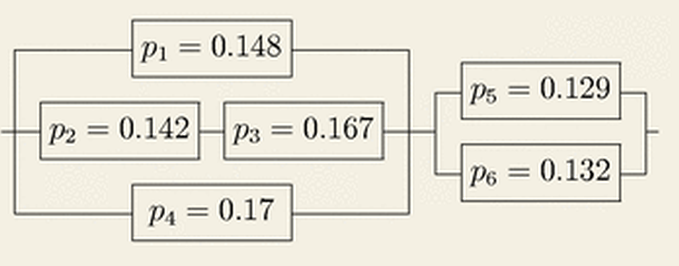

(p1 or (p2 and p3) or p4) and (p5 or p6)

In [ ]:
# Poruchovosti jednotlivých prvků
p1 = 0.148
p2 = 0.142
p3 = 0.167
p4 = 0.17
p5 = 0.129
p6 = 0.132

# Spolehlivosti jednotlivých prvků
r1 = 1 - p1
r2 = 1 - p2
r3 = 1 - p3
r4 = 1 - p4
r5 = 1 - p5
r6 = 1 - p6

# Výpočet spolehlivosti podle struktury:
# (p1 or (p2 and p3) or p4) and (p5 or p6)

# Levá větev: OR mezi p1, (p2 AND p3), p4
left_branch = 1 - ((1 - r1) * (1 - (r2 * r3)) * (1 - r4))

# Pravá větev: OR mezi p5 a p6
right_branch = 1 - ((1 - r5) * (1 - r6))

# Celková spolehlivost systému
system_reliability = left_branch * right_branch
system_failure = 1 - system_reliability

print(f"Spolehlivost systému: {system_reliability:.4f}")
print(f"Poruchovost systému: {system_failure:.4f}")


Spolehlivost systému: 0.9759
Poruchovost systému: 0.0241
